# Cellpose plots
Plots for Cellpose segmentation of cells and nuclei

In [43]:
from pathlib import Path
from tifffile import imread
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sphero_vem.io import imread_downscaled, imread_labels_downscaled
from sphero_vem.segmentation.cellpose.utils import calculate_ap

plt.rcParams["font.family"] = "Arial"

In [52]:
# Define paths and models
save_root = Path("../data/figures/paper/segmentation")

pred_root = Path("../data/processed/segmented/finetuning")
image_root = Path("../data/processed/labeled/Au_01-vol_01/labeled-03")
pretrained_dir = Path(
    "../data/processed/segmented/pretrained/cellposeSAM/other-resolutions/downscaled-10"
)

model_cells = "cellposeSAM-cells-ds10-20250911_174443"
model_nuclei = "cellposeSAM-nuclei-ds10-20250911_181746"

gt_root = image_root / "labels"
cells_dir = pred_root / model_cells
nuclei_dir = pred_root / model_nuclei

In [ ]:
# Get image paths
cells_pred_paths = [i for i in cells_dir.glob("*.tif") if "virt" not in i.name]
cells_gt_paths = [gt_root / i.name for i in cells_pred_paths]
cells_image_paths = [
    image_root / i.name.replace("-cells", "") for i in cells_pred_paths
]

nuclei_pred_paths = [i for i in nuclei_dir.glob("*.tif") if "virt" not in i.name]
nuclei_gt_paths = [gt_root / i.name for i in nuclei_pred_paths]
nuclei_image_paths = [
    image_root / i.name.replace("-nuclei", "") for i in nuclei_pred_paths
]

cells_pred_paths_pretrained = [
    i
    for i in pretrained_dir.glob("*cells.tif")
    if i.name in [j.name for j in cells_pred_paths]
]
nuclei_pred_paths_pretrained = [
    i
    for i in pretrained_dir.glob("*nuclei.tif")
    if i.name in [j.name for j in nuclei_pred_paths]
]

# Read data
cells_data = [
    {
        "image": imread_downscaled(image, 2),
        "gt": imread_labels_downscaled(gt, 2),
        "pred": imread(pred),
        "pretrained": imread(pt),
        "name": image.name,
    }
    for image, gt, pred, pt in zip(
        cells_image_paths, cells_gt_paths, cells_pred_paths, cells_pred_paths_pretrained
    )
]

nuclei_data = [
    {
        "image": imread_downscaled(image, 2),
        "gt": imread_labels_downscaled(gt, 2),
        "pred": imread(pred),
        "pretrained": imread(pt),
        "name": image.name,
    }
    for image, gt, pred, pt in zip(
        nuclei_image_paths,
        nuclei_gt_paths,
        nuclei_pred_paths,
        nuclei_pred_paths_pretrained,
    )
]

In [45]:
# Calculate average precision
results = []
for item in cells_data:
    results.append(
        calculate_ap(item["gt"], item["pred"]).assign(
            **{"model": "Finetuned", "seg_target": "cells", "name": item["name"]}
        )
    )
    results.append(
        calculate_ap(item["gt"], item["pretrained"]).assign(
            **{"model": "Pretrained", "seg_target": "cells", "name": item["name"]}
        )
    )

for item in nuclei_data:
    results.append(
        calculate_ap(item["gt"], item["pred"]).assign(
            **{"model": "Finetuned", "seg_target": "nuclei", "name": item["name"]}
        )
    )
    results.append(
        calculate_ap(item["gt"], item["pretrained"]).assign(
            **{"model": "Pretrained", "seg_target": "nuclei", "name": item["name"]}
        )
    )

results: pd.DataFrame = pd.concat(results)
grouped = results.groupby(["seg_target", "model", "iou_thresholds"], as_index=False)[
    "average_precision"
].aggregate("mean")

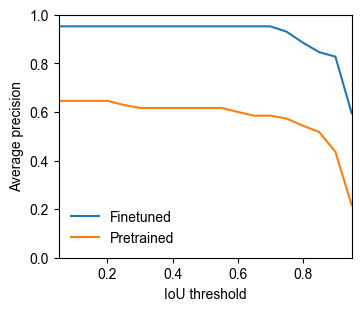

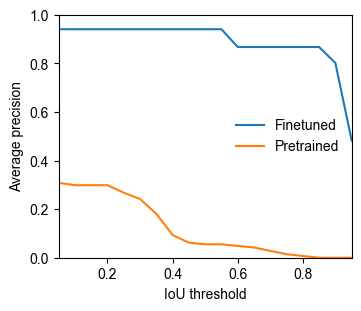

In [54]:
for seg_target in ["cells", "nuclei"]:
    fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
    sns.lineplot(
        data=grouped.query(f"seg_target=='{seg_target}'"),
        x="iou_thresholds",
        y="average_precision",
        hue="model",
    )
    ax.set(
        xlim=[0.05, 0.95],
        ylim=[0, 1],
        xlabel="IoU threshold",
        ylabel="Average precision",
    )
    leg = ax.get_legend()
    leg.set(title="", frame_on=False)
    # for text in leg.get_texts():
    #     text.set_fontsize(8)
    fig.savefig(
        save_root / f"Cellpose-ap-{seg_target}.pdf",
        bbox_inches="tight",
        pad_inches=0.01,
    )